# 📊 Hotel Price Data — Exploration & Preprocessing

This notebook loads Indian hotel pricing data from Kaggle (6 city CSVs),
performs exploratory data analysis (EDA), engineers features, and saves the
preprocessed dataset for model training.

**Dataset**: Hotel Price Data of Cities in India (MakeMyTrip / Kaggle)

---

## 1. Install & Import Libraries

In [1]:
!pip install -q opendatasets pandas numpy matplotlib seaborn scikit-learn

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Dataset from Kaggle

We load the **Hotel Price Data of Cities in India** from Kaggle.
The dataset contains 6 CSVs — one per city:
`bangalore.csv`, `chennai.csv`, `delhi.csv`, `hyderabad.csv`, `kolkata.csv`, `mumbai.csv`.

If the dataset is unavailable, we generate a realistic synthetic dataset.

In [3]:
# --- Option 1: Try loading from Kaggle via opendatasets ---
DATASET_LOADED = False

try:
    import opendatasets as od
    od.download('https://www.kaggle.com/datasets/andrewgeorgeissac/hotel-price-data-of-cities-in-india-makemytrip')
    dataset_dir = 'hotel-price-data-of-cities-in-india-makemytrip'

    if os.path.exists(dataset_dir):
        csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]
        if csv_files:
            # Load ALL CSV files and add a City column from the filename
            dfs = []
            for csv_file in sorted(csv_files):
                city_name = os.path.splitext(csv_file)[0].title()  # e.g. 'bangalore' -> 'Bangalore'
                df_city = pd.read_csv(os.path.join(dataset_dir, csv_file))
                df_city['City'] = city_name
                dfs.append(df_city)
                print(f'  ✅ Loaded {csv_file} — {df_city.shape[0]} hotels ({city_name})')

            raw_df = pd.concat(dfs, ignore_index=True)
            DATASET_LOADED = True
            print(f'\n✅ Combined Kaggle dataset: {raw_df.shape[0]} hotels across {len(csv_files)} cities')

except Exception as e:
    print(f'⚠️  Could not download Kaggle dataset: {e}')

if not DATASET_LOADED:
    print('📝 Will generate synthetic Indian hotel dataset instead.')

Skipping, found downloaded files in ".\hotel-price-data-of-cities-in-india-makemytrip" (use force=True to force download)
  ✅ Loaded bangalore.csv — 101 hotels (Bangalore)
  ✅ Loaded chennai.csv — 101 hotels (Chennai)
  ✅ Loaded delhi.csv — 101 hotels (Delhi)
  ✅ Loaded hyderabad.csv — 75 hotels (Hyderabad)
  ✅ Loaded kolkata.csv — 101 hotels (Kolkata)
  ✅ Loaded mumbai.csv — 101 hotels (Mumbai)

✅ Combined Kaggle dataset: 580 hotels across 6 cities


## 3. Generate Synthetic Indian Hotel Dataset (Fallback)

Creates a realistic dataset with Indian cities, hotel data, and pricing.
This cell only runs if the Kaggle download failed.

In [4]:
if not DATASET_LOADED:
    np.random.seed(42)
    n_samples = 15000

    cities_info = {
        'Mumbai': {'state': 'Maharashtra', 'base_price': 5500, 'tier': 1},
        'Delhi': {'state': 'Delhi', 'base_price': 5000, 'tier': 1},
        'Bangalore': {'state': 'Karnataka', 'base_price': 4800, 'tier': 1},
        'Chennai': {'state': 'Tamil Nadu', 'base_price': 4200, 'tier': 1},
        'Kolkata': {'state': 'West Bengal', 'base_price': 3800, 'tier': 1},
        'Hyderabad': {'state': 'Telangana', 'base_price': 4500, 'tier': 1},
        'Pune': {'state': 'Maharashtra', 'base_price': 3500, 'tier': 2},
        'Jaipur': {'state': 'Rajasthan', 'base_price': 4000, 'tier': 2},
        'Ahmedabad': {'state': 'Gujarat', 'base_price': 3200, 'tier': 2},
        'Goa': {'state': 'Goa', 'base_price': 5200, 'tier': 2},
        'Udaipur': {'state': 'Rajasthan', 'base_price': 5000, 'tier': 2},
        'Shimla': {'state': 'Himachal Pradesh', 'base_price': 4000, 'tier': 2},
        'Manali': {'state': 'Himachal Pradesh', 'base_price': 3800, 'tier': 2},
        'Kochi': {'state': 'Kerala', 'base_price': 3600, 'tier': 2},
        'Agra': {'state': 'Uttar Pradesh', 'base_price': 3200, 'tier': 2},
        'Varanasi': {'state': 'Uttar Pradesh', 'base_price': 2800, 'tier': 3},
        'Mysore': {'state': 'Karnataka', 'base_price': 2600, 'tier': 3},
        'Rishikesh': {'state': 'Uttarakhand', 'base_price': 3000, 'tier': 3},
        'Darjeeling': {'state': 'West Bengal', 'base_price': 3200, 'tier': 3},
        'Ooty': {'state': 'Tamil Nadu', 'base_price': 3000, 'tier': 3},
        'Coorg': {'state': 'Karnataka', 'base_price': 3500, 'tier': 3},
        'Amritsar': {'state': 'Punjab', 'base_price': 2800, 'tier': 3},
        'Jodhpur': {'state': 'Rajasthan', 'base_price': 3200, 'tier': 3},
        'Leh': {'state': 'Ladakh', 'base_price': 4500, 'tier': 3},
        'Andaman': {'state': 'Andaman & Nicobar', 'base_price': 5000, 'tier': 3},
    }

    room_types = ['Standard', 'Deluxe', 'Suite', 'Premium', 'Executive']
    room_multiplier = {'Standard': 1.0, 'Deluxe': 1.6, 'Suite': 2.8, 'Premium': 2.1, 'Executive': 1.9}

    seasons = ['Summer', 'Winter', 'Monsoon', 'Spring', 'Autumn']
    season_multiplier = {'Summer': 1.15, 'Winter': 1.25, 'Monsoon': 0.80, 'Spring': 1.0, 'Autumn': 0.90}

    city_names = list(cities_info.keys())

    data = []
    for _ in range(n_samples):
        city = np.random.choice(city_names)
        info = cities_info[city]
        room = np.random.choice(room_types)
        season = np.random.choice(seasons)
        num_guests = np.random.randint(1, 7)
        is_weekend = np.random.choice([0, 1], p=[0.6, 0.4])
        has_events = np.random.choice([0, 1], p=[0.75, 0.25])

        # Calculate price with realistic factors
        base = info['base_price']
        price = base * room_multiplier[room] * season_multiplier[season]
        price *= (1.2 if is_weekend else 1.0)
        price *= (1.3 if has_events else 1.0)
        price *= (1.0 + (num_guests - 1) * 0.08)
        # Add noise
        price *= np.random.uniform(0.85, 1.15)
        price = round(price, 2)

        data.append({
            'city': city,
            'state': info['state'],
            'room_type': room,
            'season': season,
            'num_guests': num_guests,
            'is_weekend': is_weekend,
            'has_events': has_events,
            'price': price
        })

    raw_df = pd.DataFrame(data)
    print(f'✅ Generated synthetic dataset: {raw_df.shape}')

raw_df.head(10)

,Hotel Name,Rating,Rating Description,Reviews,Star Rating,Location,Nearest Landmark,Distance to Landmark,Price,Tax,City
0,The Park Bangalore,3.9,Very Good,4187.0,5.0,Ulsoor,NaN,NaN,"7,567","2,254",Bangalore
1,"Keys Select by Lemon Tree Hotels, Whitefield, ...",4.0,Very Good,2201.0,4.0,Brookefield,NaN,NaN,"1,509",531,Bangalore
2,ITC Windsor - A Luxury Collection Hotel,4.4,Excellent,1315.0,5.0,Vasanth Nagar,Bangalore Palace,2.4 km,"9,900",NaN,Bangalore
3,Lemon Tree Premier Ulsoor Lake Bangalore,4.0,Very Good,5089.0,5.0,Sivanchetti Gardens,Ulsoor Lake,770 m,"2,347",918,Bangalore
4,"Keys Select by Lemon Tree Hotels, Hosur Road, ...",4.0,Very Good,3290.0,4.0,Hosur road,NaN,NaN,"2,522","1,014",Bangalore
5,The Chancery Pavilion,3.8,Very Good,4764.0,5.0,Ashok Nagar,MG Road,2.4 km,"6,580","1,540",Bangalore
6,Radisson Blu Atria Bengaluru,4.3,Excellent,2372.0,5.0,Palace road,NaN,NaN,"10,200",NaN,Bangalore
7,Lemon Tree Hotel Electronics City Bangalore,4.1,Very Good,2314.0,4.0,Electronic City,NaN,NaN,"2,598","1,016",Bangalore
8,"Welcomhotel by ITC Hotels, Richmond Road, Beng...",4.3,Excellent,2076.0,5.0,Richmond road,NaN,NaN,"7,700",NaN,Bangalore
9,Grand Mercure Bangalore - An Accor Brand,4.3,Excellent,426.0,5.0,Koramangala,NaN,NaN,"9,700",NaN,Bangalore


## 4. Data Cleaning & Overview

Clean the raw data: parse `Price` and `Tax` from comma-separated strings to
numeric values, handle missing data, etc.

In [5]:
# --- Data Cleaning (only needed for Kaggle data) ---
if DATASET_LOADED:
    # Clean Price: remove commas, convert to numeric
    raw_df['Price'] = raw_df['Price'].astype(str).str.replace(',', '', regex=False)
    raw_df['Price'] = pd.to_numeric(raw_df['Price'], errors='coerce')

    # Clean Tax: remove commas, convert to numeric
    raw_df['Tax'] = raw_df['Tax'].astype(str).str.replace(',', '', regex=False)
    raw_df['Tax'] = pd.to_numeric(raw_df['Tax'], errors='coerce')

    # Parse Distance to Landmark to numeric km
    def parse_distance(val):
        if pd.isna(val) or str(val).strip() == '':
            return np.nan
        val = str(val).strip().lower()
        match = re.match(r'([\d.]+)\s*(km|m)', val)
        if match:
            num = float(match.group(1))
            unit = match.group(2)
            return num if unit == 'km' else num / 1000.0
        return np.nan

    raw_df['Distance_km'] = raw_df['Distance to Landmark'].apply(parse_distance)

    # Create has_landmark flag
    raw_df['Has_Landmark'] = raw_df['Nearest Landmark'].notna().astype(int)

    # Fill missing Star Rating with median
    raw_df['Star Rating'] = raw_df['Star Rating'].fillna(raw_df['Star Rating'].median())

    # Fill missing Rating/Reviews with median
    raw_df['Rating'] = raw_df['Rating'].fillna(raw_df['Rating'].median())
    raw_df['Reviews'] = raw_df['Reviews'].fillna(raw_df['Reviews'].median())

    # Fill missing Tax with 0
    raw_df['Tax'] = raw_df['Tax'].fillna(0)

    # Fill missing Distance_km with median
    raw_df['Distance_km'] = raw_df['Distance_km'].fillna(raw_df['Distance_km'].median())

    # Drop rows where Price is still NaN
    raw_df = raw_df.dropna(subset=['Price'])

    print(f'\nCleaned dataset shape: {raw_df.shape}')

print(f'\nShape: {raw_df.shape}')
print(f'\nColumn types:')
print(raw_df.dtypes)
print(f'\nMissing values:')
print(raw_df.isnull().sum())
print(f'\nBasic statistics:')
raw_df.describe()


Cleaned dataset shape: (580, 13)

Shape: (580, 13)

Column types:
Hotel Name               object
Rating                  float64
Rating Description       object
Reviews                 float64
Star Rating             float64
Location                 object
Nearest Landmark         object
Distance to Landmark     object
Price                     int64
Tax                     float64
City                     object
Distance_km             float64
Has_Landmark              int64
dtype: object

Missing values:
Hotel Name                0
Rating                    0
Rating Description        1
Reviews                   0
Star Rating               0
Location                  0
Nearest Landmark        290
Distance to Landmark    290
Price                     0
Tax                       0
City                      0
Distance_km               0
Has_Landmark              0
dtype: int64

Basic statistics:


,Rating,Reviews,Star Rating,Price,Tax,Distance_km,Has_Landmark
count,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000
mean,3.977414,1769.458621,4.008621,5155.370690,582.786207,4.348128,0.500000
std,0.374383,1951.054780,0.787375,6338.207546,641.545047,5.975534,0.500432
min,1.900000,3.000000,2.000000,404.000000,0.000000,0.010000,0.000000
25%,3.800000,527.750000,3.000000,2477.750000,0.000000,3.200000,0.000000
50%,4.000000,1242.000000,4.000000,3812.000000,525.500000,3.200000,0.500000
75%,4.200000,2183.000000,5.000000,6696.500000,812.500000,3.200000,1.000000
max,4.800000,15697.000000,5.000000,125000.000000,7812.000000,52.000000,1.000000


## 5. Exploratory Data Analysis (EDA)

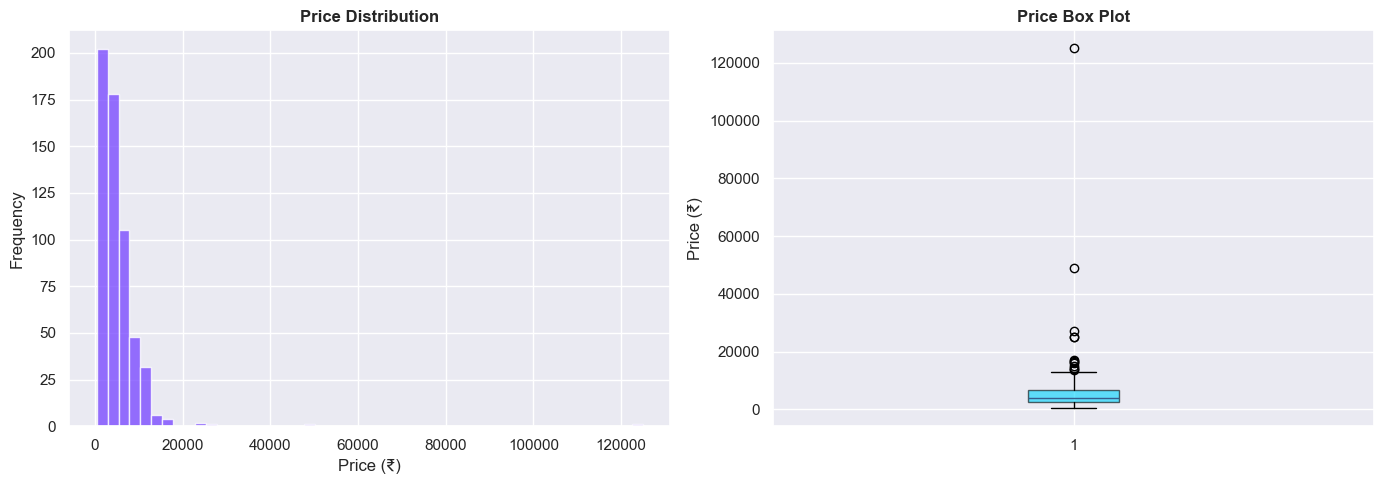

In [6]:
# Determine which column names to use based on data source
if DATASET_LOADED:
    PRICE_COL = 'Price'
    CITY_COL = 'City'
else:
    PRICE_COL = 'price'
    CITY_COL = 'city'

# 5.1 Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(raw_df[PRICE_COL], bins=50, color='#7c4dff', alpha=0.8, edgecolor='white')
axes[0].set_title('Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(raw_df[PRICE_COL].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#00d4ff', alpha=0.6))
axes[1].set_title('Price Box Plot', fontweight='bold')
axes[1].set_ylabel('Price (₹)')

plt.tight_layout()
plt.show()

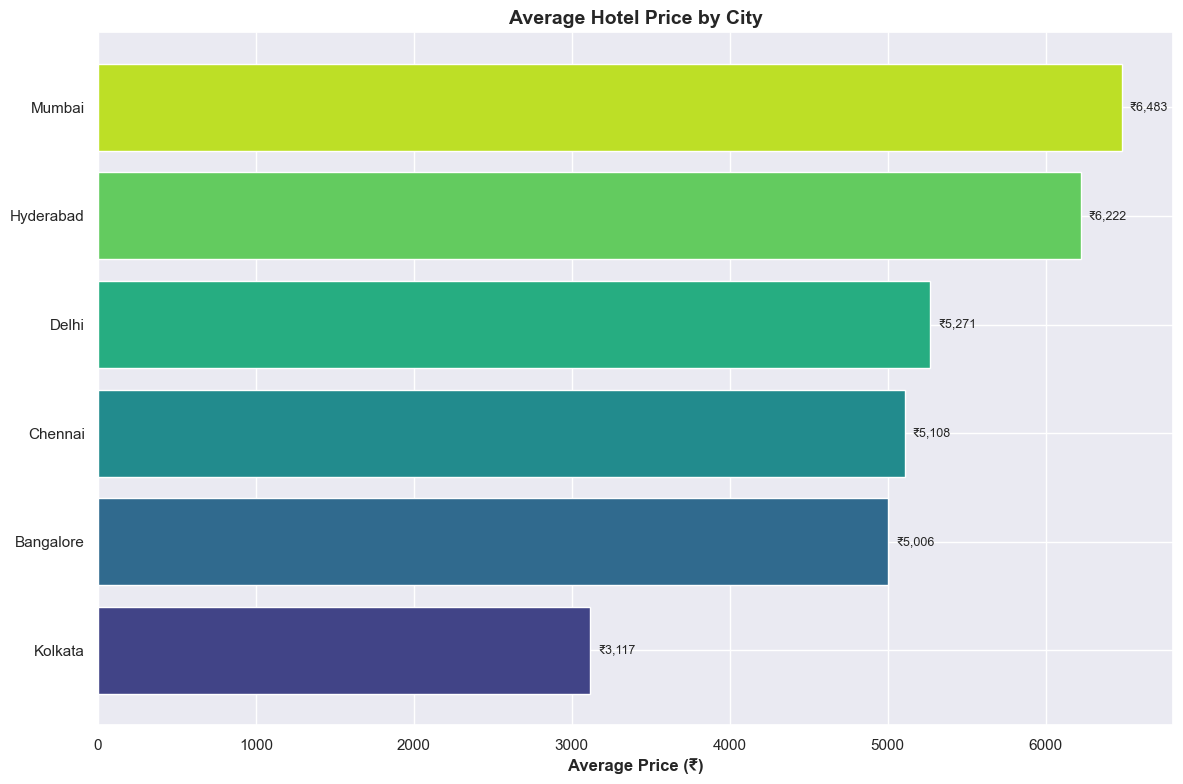

In [7]:
# 5.2 Average Price by City
city_prices = raw_df.groupby(CITY_COL)[PRICE_COL].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(city_prices.index, city_prices.values,
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(city_prices))))
ax.set_xlabel('Average Price (₹)', fontweight='bold')
ax.set_title('Average Hotel Price by City', fontweight='bold', fontsize=14)

for bar, val in zip(bars, city_prices.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'₹{val:,.0f}',
            va='center', fontsize=9, fontweight='500')

plt.tight_layout()
plt.show()

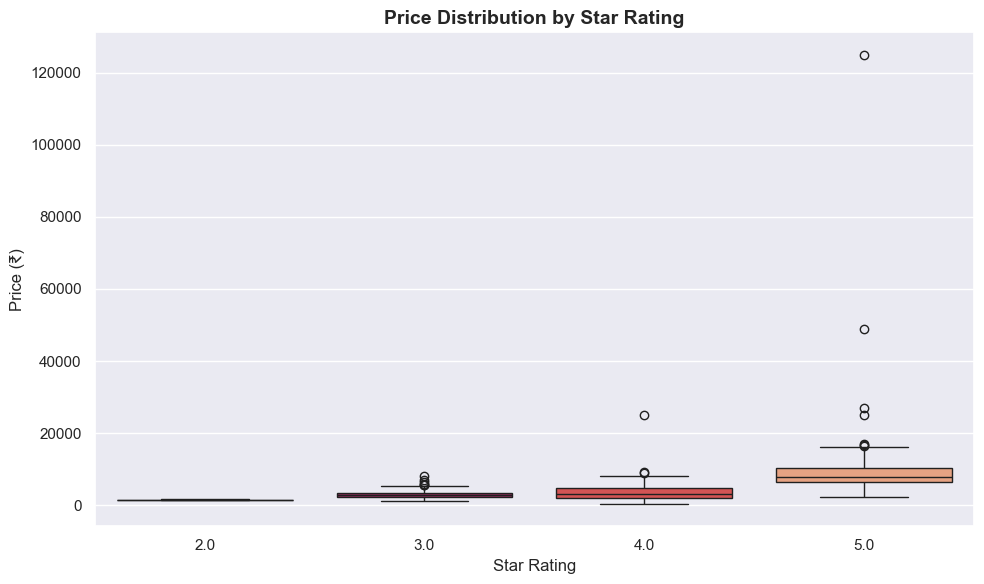

In [8]:
if DATASET_LOADED:
    # 5.3 Price by Star Rating
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=raw_df, x='Star Rating', y='Price', palette='rocket', ax=ax)
    ax.set_title('Price Distribution by Star Rating', fontweight='bold', fontsize=14)
    ax.set_xlabel('Star Rating')
    ax.set_ylabel('Price (₹)')
    plt.tight_layout()
    plt.show()
else:
    # 5.3 Price by Room Type (synthetic data)
    fig, ax = plt.subplots(figsize=(10, 6))
    room_order = raw_df.groupby('room_type')['price'].mean().sort_values().index
    sns.boxplot(data=raw_df, x='room_type', y='price', order=room_order,
                palette='rocket', ax=ax)
    ax.set_title('Price Distribution by Room Type', fontweight='bold', fontsize=14)
    ax.set_xlabel('Room Type')
    ax.set_ylabel('Price (₹)')
    plt.tight_layout()
    plt.show()

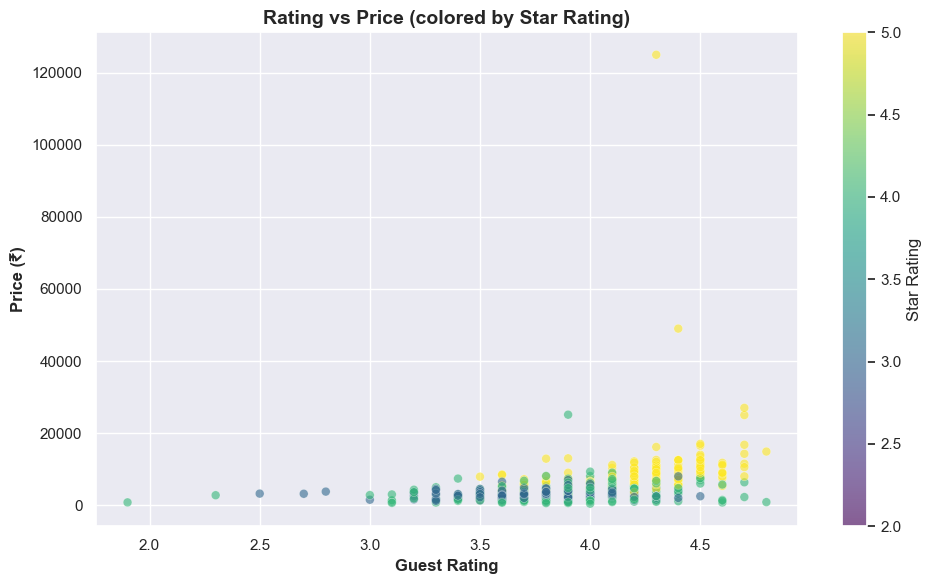

In [9]:
if DATASET_LOADED:
    # 5.4 Rating vs Price scatter
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(raw_df['Rating'], raw_df['Price'],
                         c=raw_df['Star Rating'], cmap='viridis',
                         alpha=0.6, s=40, edgecolors='w', linewidth=0.3)
    plt.colorbar(scatter, ax=ax, label='Star Rating')
    ax.set_xlabel('Guest Rating', fontweight='bold')
    ax.set_ylabel('Price (₹)', fontweight='bold')
    ax.set_title('Rating vs Price (colored by Star Rating)', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    # 5.4 Price by Season (synthetic data)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.violinplot(data=raw_df, x='season', y='price', palette='mako', ax=ax)
    ax.set_title('Price Distribution by Season', fontweight='bold', fontsize=14)
    ax.set_xlabel('Season')
    ax.set_ylabel('Price (₹)')
    plt.tight_layout()
    plt.show()

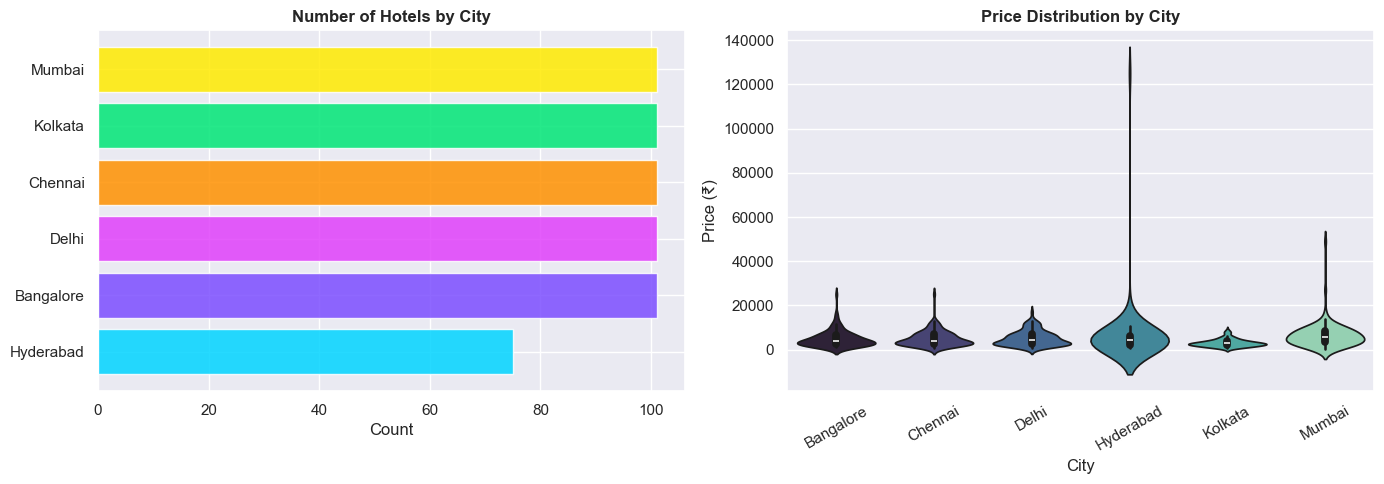

In [10]:
if DATASET_LOADED:
    # 5.5 Hotel count and price by city
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    city_counts = raw_df['City'].value_counts().sort_values(ascending=True)
    axes[0].barh(city_counts.index, city_counts.values,
                 color=['#00d4ff', '#7c4dff', '#e040fb', '#ff9100', '#00e676', '#ffea00'],
                 alpha=0.85, edgecolor='white')
    axes[0].set_title('Number of Hotels by City', fontweight='bold')
    axes[0].set_xlabel('Count')

    # Price distribution per city (violin)
    sns.violinplot(data=raw_df, x='City', y='Price', palette='mako', ax=axes[1])
    axes[1].set_title('Price Distribution by City', fontweight='bold')
    axes[1].set_ylabel('Price (₹)')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
else:
    # 5.5 Weekend vs Weekday price comparison (synthetic data)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    weekend_prices = raw_df.groupby('is_weekend')['price'].mean()
    axes[0].bar(['Weekday', 'Weekend'], weekend_prices.values,
                color=['#00d4ff', '#7c4dff'], alpha=0.85, edgecolor='white')
    axes[0].set_title('Average Price: Weekday vs Weekend', fontweight='bold')
    axes[0].set_ylabel('Average Price (₹)')

    event_prices = raw_df.groupby('has_events')['price'].mean()
    axes[1].bar(['No Events', 'Events'], event_prices.values,
                color=['#e040fb', '#ff9100'], alpha=0.85, edgecolor='white')
    axes[1].set_title('Average Price: With vs Without Events', fontweight='bold')
    axes[1].set_ylabel('Average Price (₹)')

    plt.tight_layout()
    plt.show()

## 6. Feature Engineering & Encoding

In [11]:
# Prepare the modelling dataframe
df = raw_df.copy()
label_encoders = {}

if DATASET_LOADED:
    # --- Kaggle data: feature engineering ---
    # Features: Rating, Reviews, Star Rating, City (encoded), Has_Landmark, Distance_km, Tax
    # Target: Price

    categorical_cols = ['City', 'Rating Description']
    for col in categorical_cols:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

    feature_cols_encoded = ['Rating', 'Reviews', 'Star Rating',
                            'City_encoded', 'Rating Description_encoded',
                            'Has_Landmark', 'Distance_km', 'Tax']
    target_col = 'Price'

    # Build feature matrix
    X = df[feature_cols_encoded].values
    y = df[target_col].values

else:
    # --- Synthetic data: feature engineering ---
    feature_cols = ['city', 'season', 'num_guests', 'room_type', 'is_weekend', 'has_events']
    target_col = 'price'

    categorical_cols = ['city', 'season', 'room_type']
    for col in categorical_cols:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col])
        label_encoders[col] = le
        print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

    feature_cols_encoded = ['city_encoded', 'season_encoded', 'num_guests',
                            'room_type_encoded', 'is_weekend', 'has_events']

    X = df[feature_cols_encoded].values
    y = df[target_col].values

print(f'\nFeature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\nLabel encoding complete ✅')
print('Feature scaling complete ✅')

City: {'Bangalore': np.int64(0), 'Chennai': np.int64(1), 'Delhi': np.int64(2), 'Hyderabad': np.int64(3), 'Kolkata': np.int64(4), 'Mumbai': np.int64(5)}
Rating Description: {'Average': np.int64(0), 'Excellent': np.int64(1), 'Good': np.int64(2), 'Poor': np.int64(3), 'Very Good': np.int64(4), 'nan': np.int64(5)}

Feature matrix shape: (580, 8)
Target shape: (580,)

Label encoding complete ✅
Feature scaling complete ✅


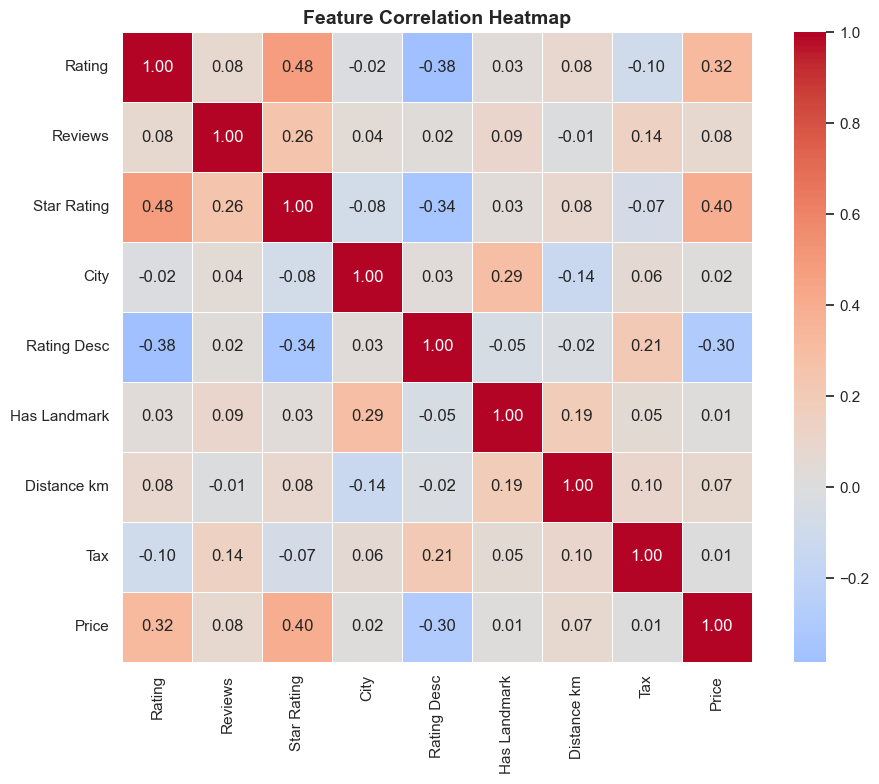

In [12]:
# 6.1 Correlation heatmap on encoded features
if DATASET_LOADED:
    feat_names = ['Rating', 'Reviews', 'Star Rating', 'City', 'Rating Desc',
                  'Has Landmark', 'Distance km', 'Tax']
else:
    feat_names = ['City', 'Season', 'Guests', 'Room Type', 'Weekend', 'Events']

encoded_df = pd.DataFrame(X_scaled, columns=feat_names)
encoded_df['Price'] = y

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(encoded_df.corr(), annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, fmt='.2f')
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 464 samples
Test set:     116 samples


## 8. Save Preprocessed Data & Artifacts

Save the preprocessed data, scaler, and label encoders so that the model notebooks can load them directly.

In [14]:
# Create models directory
os.makedirs('models', exist_ok=True)

# Save scaler and label encoders
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(label_encoders, 'models/label_encoders.pkl')

# Save train/test splits
np.savez('models/train_test_data.npz',
         X_train=X_train, X_test=X_test,
         y_train=y_train, y_test=y_test)

# Save the feature names for model notebooks to reference
if DATASET_LOADED:
    feature_names = ['Rating', 'Reviews', 'Star Rating', 'City', 'Rating Desc',
                     'Has Landmark', 'Distance km', 'Tax']
else:
    feature_names = ['City', 'Season', 'Guests', 'Room Type', 'Weekend', 'Events']

joblib.dump(feature_names, 'models/feature_names.pkl')

# Save processed dataframe for reference
df.to_csv('models/processed_data.csv', index=False)

print('✅ Saved artifacts:')
print('   models/scaler.pkl')
print('   models/label_encoders.pkl')
print('   models/train_test_data.npz')
print('   models/feature_names.pkl')
print('   models/processed_data.csv')

✅ Saved artifacts:
   models/scaler.pkl
   models/label_encoders.pkl
   models/train_test_data.npz
   models/feature_names.pkl
   models/processed_data.csv


In [15]:
print('\n🎉 Data Exploration & Preprocessing Complete!')
print('\nNext Steps:')
print('  1. Run 02_linear_regression.ipynb')
print('  2. Run 03_random_forest.ipynb')
print('  3. Run 04_gradient_boosting.ipynb')


🎉 Data Exploration & Preprocessing Complete!

Next Steps:
  1. Run 02_linear_regression.ipynb
  2. Run 03_random_forest.ipynb
  3. Run 04_gradient_boosting.ipynb
